In [1]:
"""
Breast Cancer Prediction with KNN
Author: [Your Name]
Description: Predict whether a breast tumor is malignant or benign using KNN
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
 
# Load the breast cancer dataset
print("Loading breast cancer dataset...")
cancer_data = load_breast_cancer()
 
# The dataset is a Bunch object with 'data', 'target', 'feature_names', etc.
print(f"\nDataset type: {type(cancer_data)}")
print(f"Number of samples: {len(cancer_data.data)}")
print(f"Number of features: {len(cancer_data.feature_names)}")
print(f"Original target classes: {cancer_data.target_names}")
 
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = 1 - cancer_data.target  # invert labels so 0 = benign, 1 = malignant
df['target'] = df['target'].astype(int)
 
print("\nRelabeled target classes: ['benign', 'malignant']")
 
print("\nFirst few rows:")
print(df.head())
 
print("\nDataset info:")
print(df.info())
 
print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"Benign (0): {(df['target'] == 0).sum()}")
print(f"Malignant (1): {(df['target'] == 1).sum()}")

Loading breast cancer dataset...

Dataset type: <class 'sklearn.utils._bunch.Bunch'>
Number of samples: 569
Number of features: 30
Original target classes: ['malignant' 'benign']

Relabeled target classes: ['benign', 'malignant']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069


BASIC STATISTICS
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.0

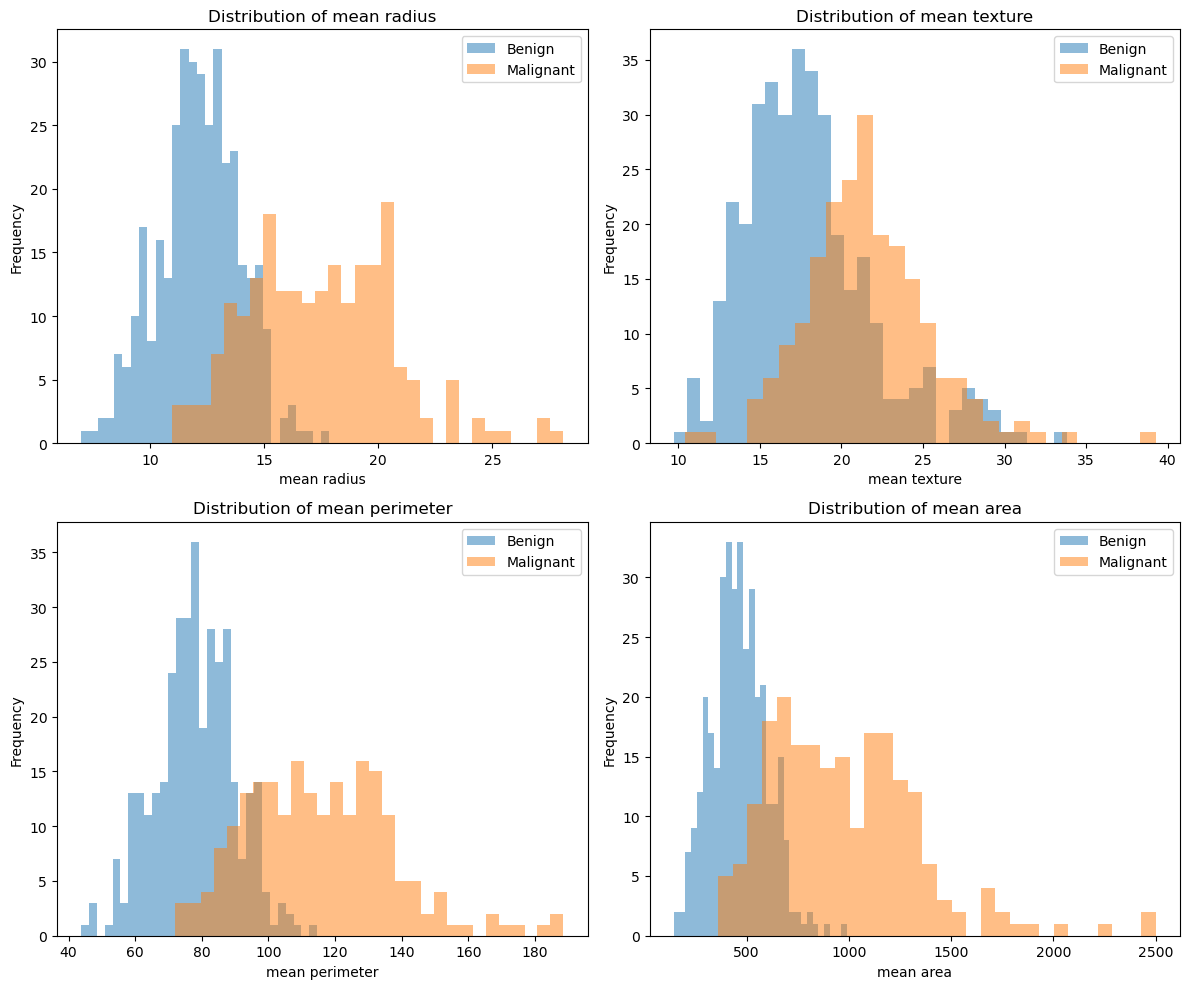

In [2]:
# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())
 
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])
 
# Visualize feature distributions (select a few key features)
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
 
for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['target'] == 0][feature], alpha=0.5, label='Benign', bins=30)
    axes[idx].hist(df[df['target'] == 1][feature], alpha=0.5, label='Malignant', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions.png'")
plt.show()

In [3]:
# Separate features and target
X = df.drop('target', axis=1)  # All columns except 'target'
y = df['target']  # Target column
 
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
 
# Split into training and testing sets
# random_state ensures reproducibility
# stratify=y ensures both sets have similar class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
 
print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")
 
# Verify class distribution in both sets
print("\nTraining set target distribution:")
print(y_train.value_counts())
print(f"  Benign (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
 
print("\nTest set target distribution:")
print(y_test.value_counts())
print(f"  Benign (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

Features shape: (569, 30)
Target shape: (569,)

DATA SPLIT
Training set size: 455 samples
Test set size: 114 samples
Training features: 30
Test features: 30

Training set target distribution:
target
0    285
1    170
Name: count, dtype: int64
  Benign (0): 285 (62.6%)
  Malignant (1): 170 (37.4%)

Test set target distribution:
target
0    72
1    42
Name: count, dtype: int64
  Benign (0): 72 (63.2%)
  Malignant (1): 42 (36.8%)


In [4]:
# Create KNN classifier
# n_neighbors=5 means the model will look at the 5 nearest neighbors to make a prediction
 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
 
print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")

KNN classifier trained successfully!
Number of neighbors (k): 5


In [5]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
 
print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")


Training predictions: 455
Test predictions: 114


In [6]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
 
print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
 
print("\n=== Confusion Matrix ===")
print("                Predicted")
print("              Benign  Malignant")
print(f"Actual Benign    {test_confusion[0,0]:4d}      {test_confusion[0,1]:4d}")
print(f"      Malignant  {test_confusion[1,0]:4d}      {test_confusion[1,1]:4d}")
 
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=cancer_data.target_names))


=== Model Performance ===

Training Accuracy: 0.9495 (94.95%)
Test Accuracy: 0.9123 (91.23%)

Test Precision: 0.9706
Test Recall: 0.7857

=== Confusion Matrix ===
                Predicted
              Benign  Malignant
Actual Benign      71         1
      Malignant     9        33

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.89      0.99      0.93        72
      benign       0.97      0.79      0.87        42

    accuracy                           0.91       114
   macro avg       0.93      0.89      0.90       114
weighted avg       0.92      0.91      0.91       114




EXPERIMENTING WITH DIFFERENT K VALUES
K= 1: Accuracy=0.8947, Precision=0.9167, Recall=0.7857
K= 3: Accuracy=0.9211, Precision=1.0000, Recall=0.7857
K= 5: Accuracy=0.9123, Precision=0.9706, Recall=0.7857
K= 7: Accuracy=0.9123, Precision=0.9706, Recall=0.7857
K= 9: Accuracy=0.9211, Precision=0.9714, Recall=0.8095
K=11: Accuracy=0.9474, Precision=1.0000, Recall=0.8571

Best K value: 11 (Accuracy: 0.9474)

Saved visualization to 'knn_k_comparison.png'


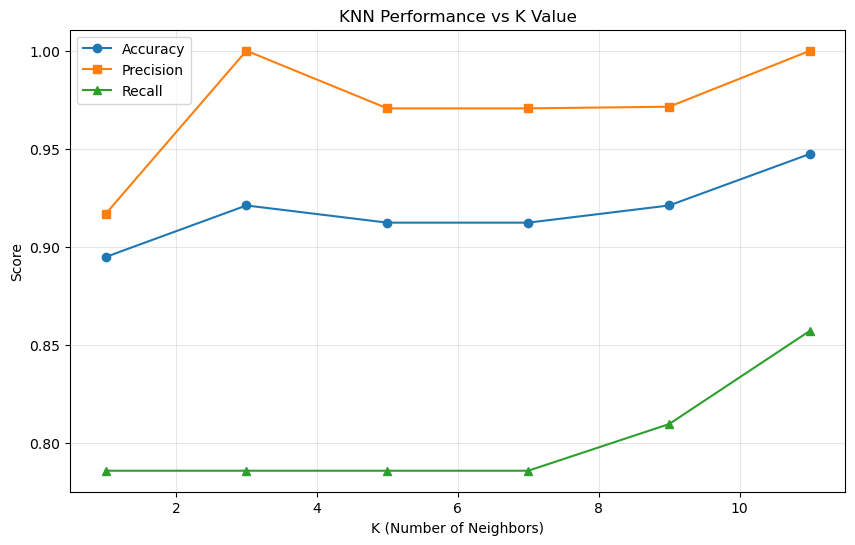

In [7]:
# Experiment with different K values
print("\n" + "="*50)
print("EXPERIMENTING WITH DIFFERENT K VALUES")
print("="*50)
 
k_values = [1, 3, 5, 7, 9, 11]
results = []
 
for k in k_values:
    # Create and train model
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = knn_temp.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
    })
    
    print(f"K={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")
 
# Find best K
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
print(f"\nBest K value: {best_k} (Accuracy: {results_df['Accuracy'].max():.4f})")
 
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['Precision'], marker='s', label='Precision')
plt.plot(results_df['K'], results_df['Recall'], marker='^', label='Recall')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('knn_k_comparison.png', dpi=150, bbox_inches='tight')
print("\nSaved visualization to 'knn_k_comparison.png'")
plt.show()

###Lab 3 - Telco Customer Churn

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
import kagglehub

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Download the Kaggle dataset and load the CSV into a pandas DataFrame
download_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_files = list(Path(download_path).glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {download_path}")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print(f"Loaded dataset from: {csv_path}")
print("\nFirst 5 records:")
print(df.head())
print(f"\nShape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget distribution:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Loaded dataset from: /Users/adamvalois/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv

First 5 records:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  .


BASIC STATISTICS
        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     7590-VHVEG   Male            NaN      No         No          NaN   
freq             1   3555            NaN    3641       4933          NaN   
mean           NaN    NaN       0.162147     NaN        NaN    32.371149   
std            NaN    NaN       0.368612     NaN        NaN    24.559481   
min            NaN    NaN       0.000000     NaN        NaN     0.000000   
25%            NaN    NaN       0.000000     NaN        NaN     9.000000   
50%            NaN    NaN       0.000000     NaN        NaN    29.000000   
75%            NaN    NaN       0.000000     NaN        NaN    55.000000   
max            NaN    NaN       1.000000     NaN        NaN    72.000000   

       PhoneService MultipleLines InternetService OnlineSecurity  ...

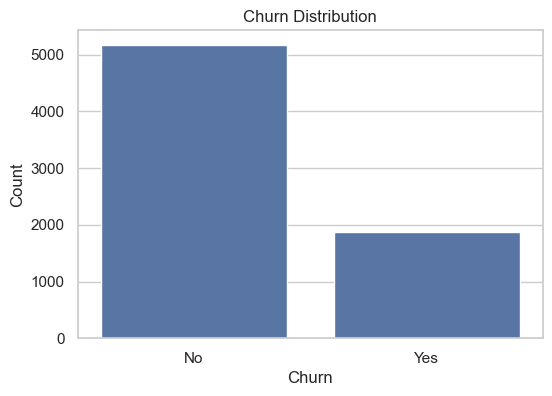

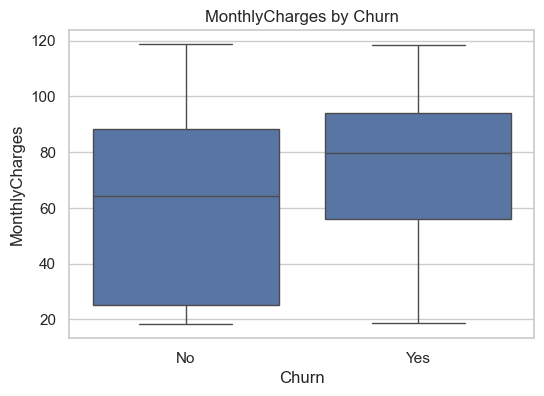

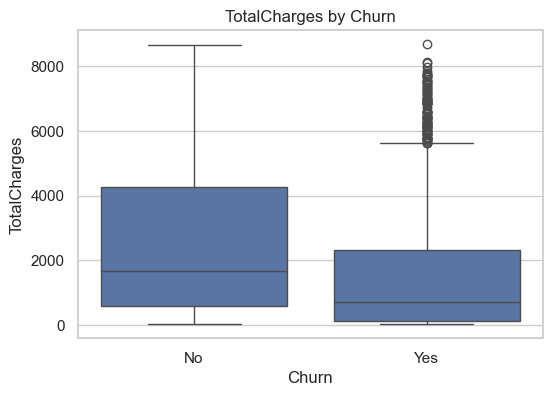

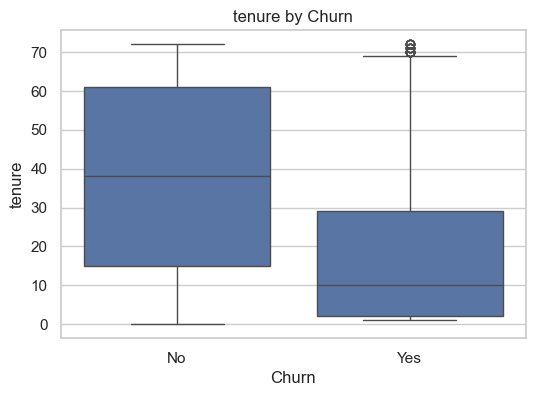

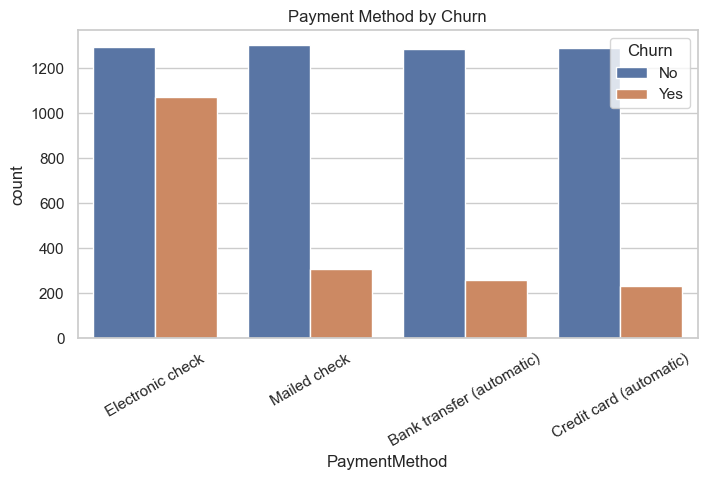

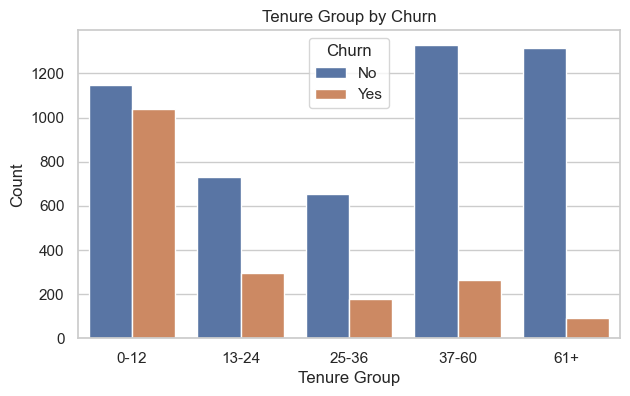

No missing values found.

Features shape: (7043, 30)
Target shape: (7043,)

Training set size: 5634
Test set size: 1409

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Test target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64

KNN model trained successfully.

Evaluation metrics:
Accuracy: 0.7658
Precision: 0.5791
Recall: 0.4305

Confusion Matrix:
[[918 117]
 [213 161]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.81      0.89      0.85      1035
       Churn       0.58      0.43      0.49       374

    accuracy                           0.77      1409
   macro avg       0.70      0.66      0.67      1409
weighted avg       0.75      0.77      0.75      1409


Interpretation:
The model predicts whether a customer will churn based on the encoded feature set.
Higher accuracy indicates better overall performance, while precision and recall show how well the model identifies churn

In [12]:
# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe(include="all"))

# Inspect target distribution visually
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Visualize a few key features
key_features = [col for col in ["MonthlyCharges", "TotalCharges", "tenure"] if col in df.columns]

for feature in key_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Churn", y=feature)
    plt.title(f"{feature} by Churn")
    plt.show()

# Add payment method and age by churn visuals
if "PaymentMethod" in df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x="PaymentMethod", hue="Churn")
    plt.title("Payment Method by Churn")
    plt.xticks(rotation=30)
    plt.show()

# Create an age-like feature from tenure if needed
if "tenure" in df.columns:
    df["age_group"] = pd.cut(
        df["tenure"],
        bins=[-1, 12, 24, 36, 60, 100],
        labels=["0-12", "13-24", "25-36", "37-60", "61+"],
    )
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x="age_group", hue="Churn")
    plt.title("Tenure Group by Churn")
    plt.xlabel("Tenure Group")
    plt.ylabel("Count")
    plt.show()

# Handle missing values
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print("Dropped rows with missing values.")
else:
    print("No missing values found.")

# Convert TotalCharges to numeric and fill any missing values
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Convert categorical variables to numeric using one-hot encoding
X = df.drop(columns=["customerID", "Churn", "age_group"])
y = df["Churn"].replace({"Yes": 1, "No": 0})

X = pd.get_dummies(X, drop_first=True)

# Separate features and target
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("\nTraining set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTest target distribution:")
print(y_test.value_counts())

# Step 4: Train a KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("\nKNN model trained successfully.")

# Step 5: Make predictions and evaluate
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nEvaluation metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

print("\nInterpretation:")
print("The model predicts whether a customer will churn based on the encoded feature set.")
print("Higher accuracy indicates better overall performance, while precision and recall show how well the model identifies churners without too many false positives.")

## Step 6 & 7: Experiment, Compare, and Interpret

This section compares several values of $k$ for the KNN classifier, identifies the best-performing setting, and summarizes what the model suggests for the business.

K= 1: Accuracy=0.7119, Precision=0.4570, Recall=0.4545
K= 3: Accuracy=0.7622, Precision=0.5657, Recall=0.4492
K= 5: Accuracy=0.7658, Precision=0.5791, Recall=0.4305
K= 7: Accuracy=0.7814, Precision=0.6260, Recall=0.4385
K= 9: Accuracy=0.7885, Precision=0.6532, Recall=0.4332
K=11: Accuracy=0.7871, Precision=0.6623, Recall=0.4037
K=15: Accuracy=0.7899, Precision=0.6726, Recall=0.4064

Best K value: 15
Best accuracy: 0.7899


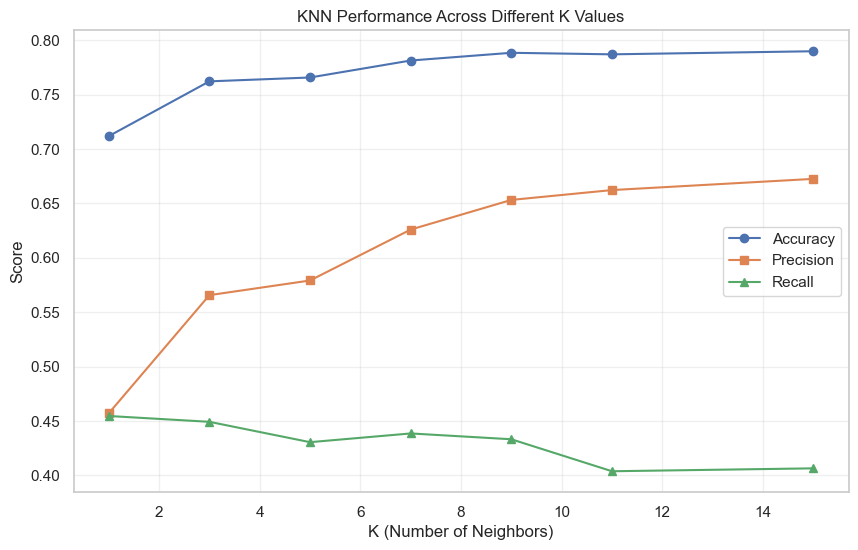


Feature insights:
- Customers with higher MonthlyCharges and longer tenure often show different churn patterns.
- Contract type and internet service appear to be strong indicators in the dataset.
- The model uses the encoded categorical features together with these numeric features to make predictions.

Business recommendation:
The company should focus retention efforts on customers who are likely to churn by targeting high-risk segments with personalized offers, proactive support, and contract-based incentives.

Model limitations:
- This is a simple KNN model and may not capture complex nonlinear relationships as well as more advanced models.
- The model depends heavily on the quality of the encoding and feature representation.
- It may be affected by class imbalance, so performance on churners could improve with more advanced balancing techniques.


In [11]:
k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)

    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)

    results.append({"K": k, "Accuracy": acc, "Precision": prec, "Recall": rec})
    print(f"K={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")

results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df["Accuracy"].idxmax(), "K"]
best_accuracy = results_df.loc[results_df["Accuracy"].idxmax(), "Accuracy"]

print("\nBest K value:", best_k)
print(f"Best accuracy: {best_accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(results_df["K"], results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["K"], results_df["Precision"], marker="s", label="Precision")
plt.plot(results_df["K"], results_df["Recall"], marker="^", label="Recall")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Score")
plt.title("KNN Performance Across Different K Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature insight based on visual exploration
print("\nFeature insights:")
print("- Customers with higher MonthlyCharges and longer tenure often show different churn patterns.")
print("- Contract type and internet service appear to be strong indicators in the dataset.")
print("- The model uses the encoded categorical features together with these numeric features to make predictions.")

print("\nBusiness recommendation:")
print("The company should focus retention efforts on customers who are likely to churn by targeting high-risk segments with personalized offers, proactive support, and contract-based incentives.")

print("\nModel limitations:")
print("- This is a simple KNN model and may not capture complex nonlinear relationships as well as more advanced models.")
print("- The model depends heavily on the quality of the encoding and feature representation.")
print("- It may be affected by class imbalance, so performance on churners could improve with more advanced balancing techniques.")